 TIME-SERIES 
Target Field: Tmax
   [+] Processing Venus_Imp5...
   [OK] Venus_Imp5 added to plot.
   [+] Processing Venus_Imp6...
   [OK] Venus_Imp6 added to plot.

[SUCCESS] Plot saved as: timeseries_Gyr_Tmax.png


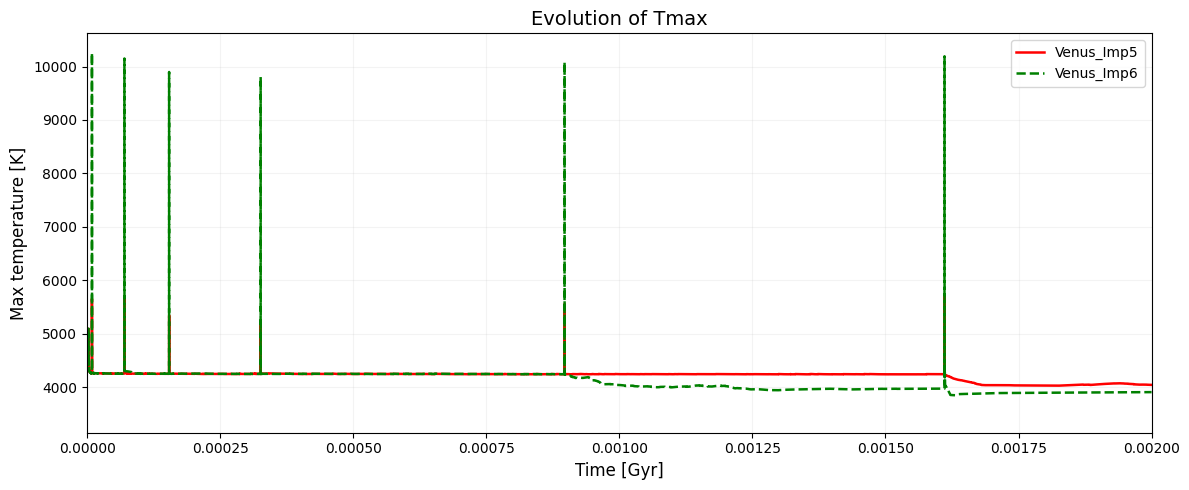

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.ticker import LogFormatterSciNotation

# StagPy is the primary library for handling StagYY output
from stagpy.stagyydata import StagyyData

# --- 1. CONSTANTS ---
SECONDS_IN_GYR = 3.15576e7 * 1e9

# Try to import Fabio Crameri's colormaps; fallback if not installed
try:
    from cmcrameri import cm
    HAS_CRAMERI = True
except ImportError:
    HAS_CRAMERI = False

# --- 2. CONFIGURATION ---

# Define your runs, their system paths, and visual styles here.
# Note: 'color' can be a name (e.g., 'red'), None, or "none" to use Crameri's colourmaps.
RUN_CONFIG = {
    "Venus_Imp5": {
        "path": "/media/aritro/f522493b-003a-404d-a839-3e0925c674b6/Aritro/StagYY/runs/festus/venus_imp5/archive/",
        "style": "-",      
        "color": "red"    
    },
    "Venus_Imp6": {
        "path": "/media/aritro/f522493b-003a-404d-a839-3e0925c674b6/Aritro/StagYY/runs/festus/venus_imp6/archive/",
        "style": "--",     
        "color": "green"     
    },
}

field_to_plot = "Tmax" 

# --- AXIS LIMITS ---
# Set X_LIMITS to (min, max) in Gyr, or None for automatic scaling
X_LIMITS = (0,0.002) 

# MANUAL Y-AXIS LIMITS:
# Add fields here to force specific Y-axis ranges (min, max).
FIELD_LIMITS = {
    "Tmean": (500, 4000),
    "Vrms": (1e-8, 1e-2),
    "F_mean": (0, 0.5),
    "eta_max": (1e21, 1e27),
}

# --- VISUAL OPTIONS ---
USE_CRAMERI = True
SEQUENTIAL_MAP = "roma"
DIVERGING_MAP  = "nuuk"

# --- 3. REFERENCE: ALL TIME SERIES PARAMETERS ---
ALL_TIME_FIELDS = {
    # Basic Physics & Dynamics
    "time": "Time",
    "dt": "Time increment",
    "dTdt": "Time derivative of temperature",
    "Vmin": "Min velocity",
    "Vrms": "rms velocity",
    "Vmax": "Max velocity",
    "ra_eff": "Effective Ra",
    "mobility": "Plates mobility",
    "ebalance": "Energy balance",

    # Thermal State
    "Tmin": "Min temperature",
    "Tmean": "Temperature",
    "Tmax": "Max temperature",
    "Tsurf": "Temperature at top",
    "Tcmb": "Temperature at bottom",
    "Tpotl": "Mass mean potential temperature",
    "ts_core": "Temperature at core surface",
    "tc_core": "Temperature at center",

    # Heat Flux & Nusselt
    "F_top": "Heat flux at top",
    "F_bot": "Heat flux at bottom",
    "Nu_top": "Nusselt at top",
    "Nu_bot": "Nusselt at bot",

    # Rheology (Viscosity)
    "eta_min": "Min viscosity",
    "eta_amean": "Viscosity (Arithmetic)",
    "eta_max": "Max viscosity",
    "eta_gmean": "Geometric mass mean viscosity",

    # Melting & Volcanism
    "F_mean": "Molten fraction",
    "F_max": "Max molten fraction",
    "erupt_rate": "Eruption rate",
    "erupta": "Erupta total",
    "erupta_total": "Total erupta",
    "erupt_heatflux": "Erupta heat",
    "intruda": "Intruda",
    "H_melt": "Melting heat flux",

    # Heating Sources/Sinks
    "H_int": "Internal heating",
    "H_diffus": "Heat diffusion",
    "H_VD": "Viscous dissipation",
    "H_AH": "Adiabatic heating",
    "H_cool": "Cooling",
    "H_impacts": "Impact heating",

    # Composition & Tracers
    "C_min": "Min concentration",
    "C_mean": "Concentration",
    "C_max": "Max concentration",
    "entrainment": "Entrainment",
    "Cmass_error": "Error on Cmass",
    "denstramin": "Min tracers density",
    "denstramean": "Tracers density",
    "denstramax": "Max tracers density",

    # Volatiles & Noble Gases
    "mH2O_total": "Total H2O mass",
    "mH2O_mantle": "H2O in mantle",
    "outgassed_H2O": "H2O outgassed",
    "outgassed_CO2": "CO2 outgassed",
    "outgassed_N2": "N2 outgassed",
    "outgassed_40Ar": "40Ar outgassed",
    "outgassed_4He": "4He outgassed",
    
    # Core & Geometry
    "r_innercore": "Inner core radius",
    "s_core": "Core size",
    "Psurf": "Ground pressure",
}

# --- 4. MAIN EXECUTION ---

def main():
    print(f"{'='*60}\n TIME-SERIES \n{'='*60}")
    print(f"Target Field: {field_to_plot}")

    try:
        # Initialize Figure
        fig, ax = plt.subplots(figsize=(12, 5)) 
        labels_set = False
        
        # Determine if we should use a diverging color map
        diverging_keywords = ["dt", "balance", "cool", "flux", "diff"]
        is_diverging = any(k in field_to_plot.lower() for k in diverging_keywords)
        
        num_runs = len(RUN_CONFIG)
        
        # Handle automatic color generation
        auto_colors = [None] * num_runs
        if USE_CRAMERI and HAS_CRAMERI:
            cmap_name = DIVERGING_MAP if is_diverging else SEQUENTIAL_MAP
            cmap_obj = getattr(cm, cmap_name)
            auto_colors = [cmap_obj(i / (num_runs - 1)) if num_runs > 1 else cmap_obj(0.5) for i in range(num_runs)]

        # --- Data Processing Loop ---
        for idx, (run_label, cfg) in enumerate(RUN_CONFIG.items()):
            try:
                # 1. Path Validation
                run_path = Path(cfg["path"])
                if not run_path.exists():
                    print(f"   [!] FAILED: Path does not exist for {run_label}")
                    continue
                
                print(f"   [+] Processing {run_label}...")
                
                # 2. Load Data and Access Field
                sdata = StagyyData(run_path)
                ts_data = sdata.tseries[field_to_plot]
                
                # 3. Extract and Scale
                time_gyr = ts_data.time / SECONDS_IN_GYR 
                values = ts_data.values

                # 4. Plotting
                # Logic: Use automatic Crameri colors if "color" is None or the string "none"
                if cfg["color"] is None or str(cfg["color"]).lower() == "none":
                    plot_color = auto_colors[idx]
                else:
                    plot_color = cfg["color"]

                ax.plot(time_gyr, values, 
                        label=run_label, 
                        linewidth=1.8, 
                        linestyle=cfg["style"], 
                        color=plot_color)

                # 5. Axis Labeling
                if not labels_set:
                    description = ts_data.meta.description or ALL_TIME_FIELDS.get(field_to_plot, field_to_plot)
                    unit = ts_data.meta.dim
                    if "eta" in field_to_plot and unit == "Pa": unit = "Pa s"
                    
                    ax.set_ylabel(f"{description} [{unit}]" if unit else description, fontsize=12)
                    ax.set_xlabel("Time [Gyr]", fontsize=12)
                    
                    # Logarithmic scale detection
                    log_criteria = ["log", "eta", "slog", "visc", "vrms", "vmax", "vmin", "velocity"]
                    if any(k in field_to_plot.lower() for k in log_criteria):
                        ax.set_yscale('log')
                        ax.yaxis.set_major_formatter(LogFormatterSciNotation())
                    
                    labels_set = True
                
                print(f"   [OK] {run_label} added to plot.")

            except Exception as e:
                print(f"   [!] Error: Could not process {run_label}. Detail: {e}")
                continue

        # --- Final Formatting ---
        
        # Apply manual X-limits if defined
        if X_LIMITS:
            ax.set_xlim(X_LIMITS)
            
        # Apply manual Y-limits if defined for this field
        if field_to_plot in FIELD_LIMITS:
            ax.set_ylim(FIELD_LIMITS[field_to_plot])
            print(f"   [i] Manual Y-limits applied: {FIELD_LIMITS[field_to_plot]}")

        ax.legend(loc='best', frameon=True)
        ax.grid(True, which="both", ls="-", alpha=0.15)
        ax.set_title(f"Evolution of {field_to_plot}", fontsize=14)
        
        plt.tight_layout()

        save_name = f"timeseries_Gyr_{field_to_plot}.png"
        fig.savefig(save_name, dpi=300)
        
        print(f"\n{'='*60}")
        print(f"[SUCCESS] Plot saved as: {save_name}")
        print(f"{'='*60}")
        
        plt.show()

    except Exception as e:
        print(f"\n[CRITICAL ERROR]: {e}")

if __name__ == "__main__":
    main()